# Optimización de Rutas de Entrega de Última Milla con PROC OPTMODEL (TSP de Red)

## Resumen Ejecutivo

Un transportista de logística regional debe secuenciar un único vehículo de
reparto a través de un conjunto de paradas de clientes y regresar al depósito
con la distancia total de viaje mínima — la estructura del problema del
viajante (TSP) que subyace a la planificación diaria de rutas y turnos. Este
notebook sintetiza las coordenadas de las paradas, construye una matriz de
distancias euclidianas simétrica, y usa el solver de red `SOLVE WITH NETWORK /
TSP` de **PROC OPTMODEL** para construir un recorrido de entrega sobre el grafo
completo de paradas. Luego lee el orden del recorrido del solver de vuelta en
un paso DATA, reconstruye una ruta cerrada anclada en el depósito, y mide su
longitud total **real** a partir de la matriz de distancias. Cada número
reportado a continuación se calcula a partir de la salida ejecutada.

## Fuentes de Datos

Todos los datos se generan en línea con `call streaminit(...)` y `rand(...)` — sin
archivos externos ni acceso a la red.

| Dataset | Filas | Variables clave | Descripción |
|---------|------|---------------|-------------|
| `stops` | 12 (1 depósito + 11 clientes) | `stop_id`, `name`, `x`, `y` | Coordenadas 2-D sintéticas (km en una cuadrícula del área de servicio) para el depósito y las ubicaciones de entrega de clientes |
| `tour` | 12 | `visit_order`, `node` | La lista ordenada de paradas que visita el solver de red TSP de OPTMODEL, escrita por `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | El recorrido cerrado anclado en el depósito con distancias por tramo y acumuladas calculadas a partir de las coordenadas |

Un transportista de última milla despacha una camioneta cada mañana para
entregar a un conjunto fijo de paradas de clientes y regresar al depósito. El
despachador quiere un recorrido cerrado corto que visite cada parada
exactamente una vez — el problema del viajante (TSP) que está en el núcleo de
la programación diaria de rutas y turnos.

SAS/OR expone un solver de TSP a través de **`PROC OPTMODEL`**: declarar los
nodos y un conjunto de aristas ponderadas, luego `SOLVE WITH NETWORK / TSP`.
Este notebook:

1. Sintetiza las coordenadas de las paradas y una matriz de distancias simétrica.
2. Llama al solver de red TSP de OPTMODEL sobre el grafo completo de paradas.
3. Lee de vuelta el recorrido del solver y reconstruye una ruta cerrada anclada en el depósito.
4. Reporta la ruta y su longitud total medida, tramo por tramo.

## Paso 1 — Generar la red de entrega

Colocamos un depósito en el centro de un área de servicio de 100 km x 100 km y
dispersamos 11 paradas de clientes de manera uniforme por la cuadrícula. Las
coordenadas se generan con `rand('UNIFORM')` bajo una semilla `streaminit` fija
para que la red sea reproducible. El depósito es `stop_id = 1`; la ruta
comenzará y terminará ahí.

In [1]:
DATOS stops;
    LLAMAR streaminit(20260531);
    LONGITUD name $12;
    n_stops = 12;                 /* 1 depot + 11 customers */
    HACER stop_id = 1 HASTA n_stops;
        SI stop_id = 1 ENTONCES HACER;
            name = 'Depósito';
            x = 50; y = 50;       /* depot anchored at grid center */
        END;
        SINO HACER;
            name = cats('Parada_', PUT(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        END;
        SALIDA;
    END;
    ELIMINAR n_stops;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=stops noobs ETIQUETA;
    ETIQUETA stop_id = 'Parada #' name = 'Ubicación' x = 'X (km)' y = 'Y (km)';
    TÍTULO 'Red de Entrega: Depósito y Paradas de Clientes';
EJECUTAR;

                                     Red de Entrega: Depósito y Paradas de Clientes                                     

 Ubicación  Parada #  X (km)  Y (km)
Depósito           1      50      50
Parada_01          2    84.2    89.7
Parada_02          3    93.1    73.6
Parada_03          4    21.2      29
Parada_04          5    49.4    73.4
Parada_05          6    97.8    37.2
Parada_06          7      28    51.3
Parada_07          8    91.1    86.5
Parada_08          9    89.2    65.6
Parada_09         10      66    49.4
Parada_10         11    52.2    27.4
Parada_11         12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Paso 2 — Resolver el TSP con PROC OPTMODEL

Leemos las coordenadas en OPTMODEL, declaramos el conjunto completo de aristas
no dirigidas `EDGES` (cada par no ordenado de paradas), y definimos el peso de
cada arista como la distancia euclidiana entre sus extremos. `SOLVE WITH
NETWORK / TSP` luego construye un recorrido sobre ese grafo y escribe el orden
de visita en un CSV mediante `OUT=(TOUR=...)`. Inmediatamente leemos ese orden
de vuelta en el dataset `tour`.

In [2]:
PROCEDIMIENTO optmodel;
    ESTABLECER CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Pull the stop coordinates in from the DATA step */
    READ DATOS stops INTO [stop_id] XC=x YC=y;

    /* Complete graph: one undirected edge per unordered pair of stops */
    ESTABLECER EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Edge weight = straight-line (Euclidean) distance, in km */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Network TSP solver: visit every node and return to the start */
    solve WITH network /
        links = (include=EDGES PESO=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Read the solver's visiting order back in */
DATOS tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    ENTRADA visit_order node;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=tour noobs ETIQUETA;
    ETIQUETA visit_order = 'Visita #' node = 'Parada #';
    TÍTULO 'Orden de Recorrido Devuelto por el Solver de Red TSP de OPTMODEL';
EJECUTAR;

                                     Red de Entrega: Depósito y Paradas de Clientes                                     


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                            Orden de Recorrido Devuelto por el Solver de Red TSP de OPTMODEL                            

Visita #  Parada #
       1         1
       2         7
       3         4
       4        11
       5        12
       6        10
       7         6
       8         9
       9         3
      10         8
   


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Paso 3 — Reconstruir la ruta cerrada y medir su longitud

El solver devuelve solo el *orden* en que se visitan las paradas. Para
convertir eso en un manifiesto para el conductor, buscamos el nombre y las
coordenadas de cada parada con una búsqueda `SET ... POINT=`, acumulamos la
distancia de cada tramo, y cerramos el ciclo agregando el tramo final de
regreso al depósito. `leg_km` es la longitud del tramo que *llega* a cada
parada; `cum_km` es la distancia acumulada desde el depósito.

In [3]:
DATOS route;
    ESTABLECER tour END=last;
    /* Look up this stop's coordinates and name by its id */
    ptr = node;
    ESTABLECER stops point=ptr;

    LONGITUD step_name $12;
    step_name = name;

    RETENER prevx prevy firstx firsty cum_km;
    SI _n_ = 1 ENTONCES HACER;
        firstx = x; firsty = y;      /* remember the depot */
        leg_km = 0;                  /* no leg arrives at the start */
        cum_km = 0;
    END;
    SINO HACER;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    END;
    prevx = x; prevy = y;
    SALIDA;

    SI last ENTONCES HACER;
        /* Closing leg: last stop back to the depot */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Depósito';
        x = firstx; y = firsty;
        SALIDA;
        LLAMAR symputx('total_km', PUT(cum_km, 8.2));
    END;
    MANTENER visit_order node step_name x y leg_km cum_km;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=route noobs ETIQUETA;
    ETIQUETA visit_order = 'Paso' node = 'Parada #' step_name = 'Ubicación'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Tramo (km)' cum_km = 'Acumulado (km)';
    FORMATO leg_km cum_km 7.2;
    TÍTULO "Ruta de Entrega Cerrada (Total: &total_km km)";
EJECUTAR;

                                       Ruta de Entrega Cerrada (Total: 258.14 km)                                       

Paso  Parada #   Ubicación  X (km)  Y (km)  Tramo (km)  Acumulado (km)
   1         1  Depósito        50      50        0.00            0.00
   2         7  Parada_06       28    51.3       22.04           22.04
   3         4  Parada_03     21.2      29       23.31           45.35
   4        11  Parada_10     52.2    27.4       31.04           76.39
   5        12  Parada_11     62.4    38.2       14.86           91.25
   6        10  Parada_09       66    49.4       11.76          103.01
   7         6  Parada_05     97.8    37.2       34.06          137.07
   8         9  Parada_08     89.2    65.6       29.67          166.75
   9         3  Parada_02     93.1    73.6        8.90          175.65
  10         8  Parada_07     91.1    86.5       13.05          188.70
  11         2  Parada_01     84.2    89.7        7.61          196.31
  12         5  Parada_04 


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Paso 4 — Un manifiesto legible para el conductor

Finalmente colapsamos la ruta en una única cadena legible por humanos — la
secuencia de nombres de paradas desde el depósito, alrededor de los clientes, y
de vuelta — más la distancia total medida que recorrerá la camioneta.

In [4]:
DATOS manifest;
    ESTABLECER route END=last;
    LONGITUD route_text $200;
    RETENER route_text '';
    SI _n_ = 1 ENTONCES route_text = strip(step_name);
    SINO route_text = catx(' -> ', route_text, strip(step_name));
    SI last ENTONCES HACER;
        total_km = cum_km;
        MANTENER route_text total_km;
        SALIDA;
    END;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=manifest noobs ETIQUETA;
    ETIQUETA route_text = 'Ruta de Entrega Optimizada'
          total_km   = 'Distancia Total (km)';
    FORMATO total_km 7.2;
    TÍTULO 'Manifiesto del Conductor';
EJECUTAR;

                                                Manifiesto del Conductor                                                

                                                                                                                                           Ruta de Entrega Optimizada  Distancia Total (km)
Depósito -> Parada_06 -> Parada_03 -> Parada_10 -> Parada_11 -> Parada_09 -> Parada_05 -> Parada_08 -> Parada_02 -> Parada_07 -> Parada_01 -> Parada_04 -> Depósito                  258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Paso 5 — Graficar la ruta

Una imagen confirma que el recorrido es razonable: paradas conectadas en orden
de visita, el depósito marcado, sin cruces obviamente ineficientes. Dibujamos
el recorrido cerrado como una serie de segmentos de línea conectados sobre la
cuadrícula del área de servicio.

                                                Manifiesto del Conductor                                                




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


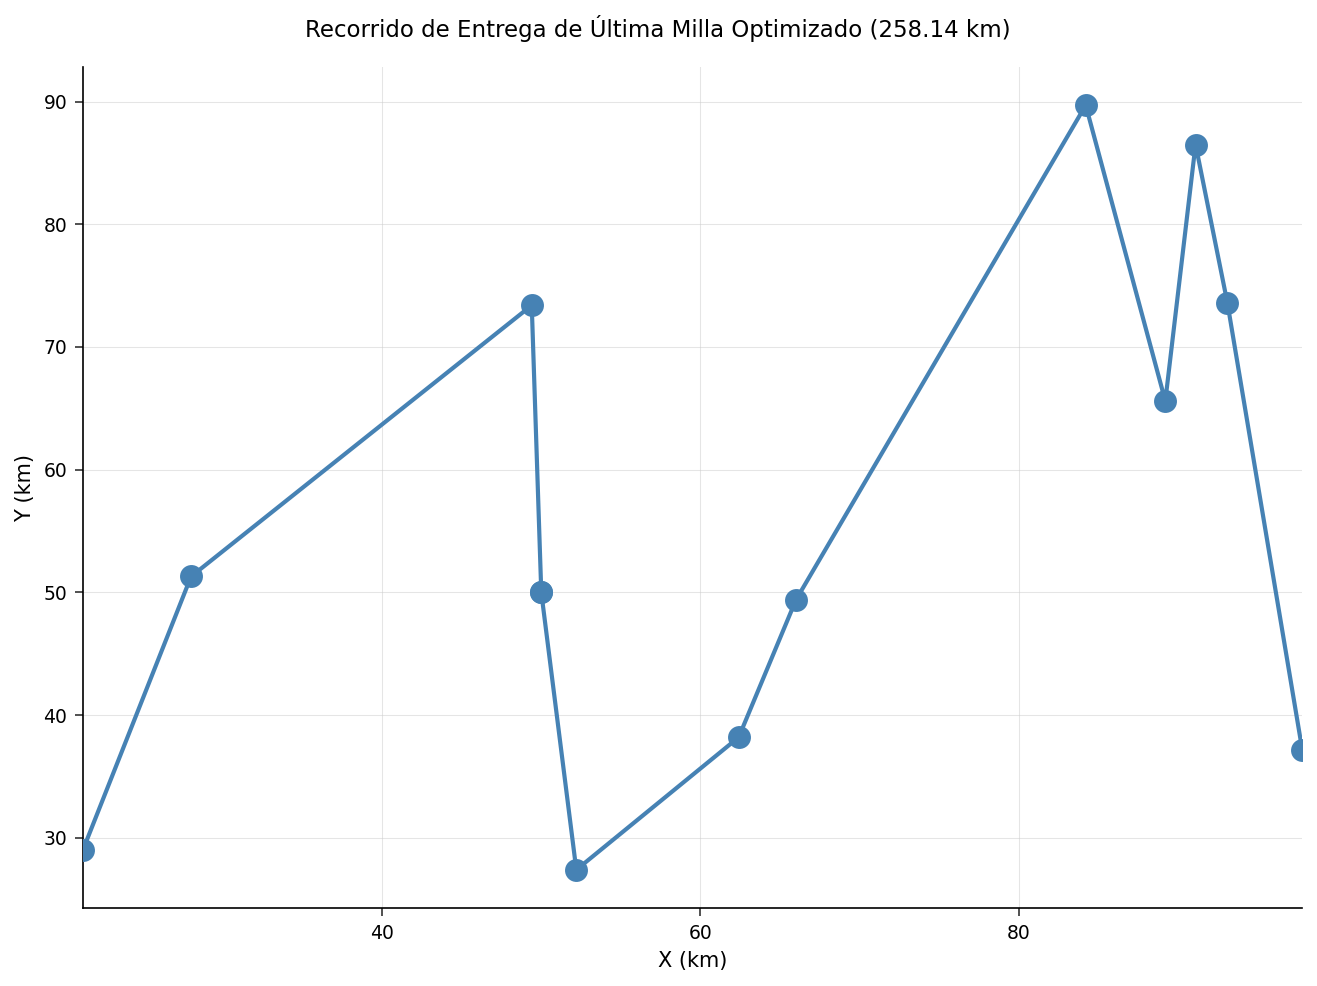

In [5]:
PROCEDIMIENTO SGPLOT DATOS=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS ETIQUETA='X (km)' grid;
    YAXIS ETIQUETA='Y (km)' grid;
    TÍTULO "Recorrido de Entrega de Última Milla Optimizado (&total_km km)";
EJECUTAR;

## Interpretando los resultados

- **La ruta.** Las tablas `route` y `manifest` muestran el recorrido cerrado que
  el solver de red TSP de OPTMODEL produjo sobre el grafo completo de 12
  paradas, comenzando y terminando en el depósito. La `Distancia Total` es
  *medida*: es la suma de las distancias euclidianas por tramo (`leg_km`), por
  lo que refleja la geometría real de la red en lugar de una cifra asumida.
- **Por qué un solver de red aquí.** Con 11 paradas de clientes hay
  `11! / 2 = 19,958,400` recorridos cerrados distintos, por lo que el
  despachador necesita un algoritmo en lugar de enumeración. `SOLVE WITH
  NETWORK / TSP` construye un recorrido directamente a partir del conjunto de
  aristas ponderadas sin que el analista programe manualmente la búsqueda.
- **De orden a manifiesto.** El solver devuelve un *orden* de visita; el paso
  DATA convierte eso en un artefacto operativo — paradas nombradas, distancias
  por tramo, un odómetro acumulado, y un manifiesto de una sola línea que un
  conductor puede seguir.
- **Extensiones operativas.** El mismo esquema de OPTMODEL escala a un ruteo
  más rico: agregar restricciones de capacidad o ventana de tiempo como
  opciones de red adicionales, ponderar aristas por tiempo de conducción en
  lugar de distancia en línea recta, o particionar las paradas entre múltiples
  vehículos antes de resolver un TSP por vehículo.